In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\win11\\Downloads\\Ecommerce_Data_Analysis\\ecommerce_sales.csv")

In [3]:
df.head()

,OrderID,OrderDate,CustomerID,City,State,ProductID,ProductName,Category,Quantity,UnitPrice,Discount,OrderStatus
0,O10001,2026-04-13,C1184,Kolkata,West Bengal,P002,Smartphone,Electronics,4,25000,15,Delivered
1,O10002,2026-09-28,C1030,Delhi,Delhi,P005,Desk Lamp,Furniture,2,1800,5,Delivered
2,O10003,2026-04-17,C1057,Pune,Maharashtra,P004,Office Chair,Furniture,2,9000,0,Delivered
3,O10004,2026-03-13,C1047,Lucknow,Uttar Pradesh,P003,Headphones,Electronics,4,2500,5,Delivered
4,O10005,2026-07-08,C1163,Hyderabad,Telangana,P007,T-Shirt,Clothing,4,1200,5,Delivered


In [4]:
df.shape

(1000, 12)

In [5]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'City', 'State', 'ProductID',
       'ProductName', 'Category', 'Quantity', 'UnitPrice', 'Discount',
       'OrderStatus'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OrderID      1000 non-null   object
 1   OrderDate    1000 non-null   object
 2   CustomerID   1000 non-null   object
 3   City         1000 non-null   object
 4   State        1000 non-null   object
 5   ProductID    1000 non-null   object
 6   ProductName  1000 non-null   object
 7   Category     1000 non-null   object
 8   Quantity     1000 non-null   int64 
 9   UnitPrice    1000 non-null   int64 
 10  Discount     1000 non-null   int64 
 11  OrderStatus  1000 non-null   object
dtypes: int64(3), object(9)
memory usage: 93.9+ KB


In [7]:
df.isnull().sum()

OrderID        0
OrderDate      0
CustomerID     0
City           0
State          0
ProductID      0
ProductName    0
Category       0
Quantity       0
UnitPrice      0
Discount       0
OrderStatus    0
dtype: int64

In [8]:
df.describe()

,Quantity,UnitPrice,Discount
count,1000.000000,1000.000000,1000.000000
mean,2.523000,10490.000000,8.570000
std,1.116565,16328.697632,5.379037
min,1.000000,1200.000000,0.000000
25%,2.000000,1800.000000,5.000000
50%,3.000000,2500.000000,10.000000
75%,4.000000,9000.000000,10.000000
max,4.000000,55000.000000,20.000000


### change the datatype of the orderdate

In [9]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      1000 non-null   object        
 1   OrderDate    1000 non-null   datetime64[ns]
 2   CustomerID   1000 non-null   object        
 3   City         1000 non-null   object        
 4   State        1000 non-null   object        
 5   ProductID    1000 non-null   object        
 6   ProductName  1000 non-null   object        
 7   Category     1000 non-null   object        
 8   Quantity     1000 non-null   int64         
 9   UnitPrice    1000 non-null   int64         
 10  Discount     1000 non-null   int64         
 11  OrderStatus  1000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 93.9+ KB


### check the duplicates

In [11]:
df["OrderID"].duplicated().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(0)

### Check for Invalid Values

In [13]:
df["Quantity"].describe()

count    1000.000000
mean        2.523000
std         1.116565
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Quantity, dtype: float64

In [14]:
df["Quantity"].value_counts().sort_index()

Quantity
1    243
2    246
3    256
4    255
Name: count, dtype: int64

In [15]:
df["Discount"].describe()

count    1000.000000
mean        8.570000
std         5.379037
min         0.000000
25%         5.000000
50%        10.000000
75%        10.000000
max        20.000000
Name: Discount, dtype: float64

In [16]:
df["Discount"].value_counts().sort_index()

Discount
0     155
5     254
10    356
15    192
20     43
Name: count, dtype: int64

In [17]:
df["OrderStatus"].value_counts()

OrderStatus
Delivered    880
Returned      74
Cancelled     46
Name: count, dtype: int64

### Create our first business column

In [18]:
df["Revenue"] = (
    df["Quantity"]
    * df["UnitPrice"]
    * (1 - df["Discount"] / 100)
)

In [19]:
df.head()

,OrderID,OrderDate,CustomerID,City,State,ProductID,ProductName,Category,Quantity,UnitPrice,Discount,OrderStatus,Revenue
0,O10001,2026-04-13,C1184,Kolkata,West Bengal,P002,Smartphone,Electronics,4,25000,15,Delivered,85000.0
1,O10002,2026-09-28,C1030,Delhi,Delhi,P005,Desk Lamp,Furniture,2,1800,5,Delivered,3420.0
2,O10003,2026-04-17,C1057,Pune,Maharashtra,P004,Office Chair,Furniture,2,9000,0,Delivered,18000.0
3,O10004,2026-03-13,C1047,Lucknow,Uttar Pradesh,P003,Headphones,Electronics,4,2500,5,Delivered,9500.0
4,O10005,2026-07-08,C1163,Hyderabad,Telangana,P007,T-Shirt,Clothing,4,1200,5,Delivered,4560.0


### Calculate Our First KPI

In [20]:
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹24,041,745.00


### Calculate Total Orders

In [21]:
total_orders = df["OrderID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 1000


### Calculate Average Order Value

In [22]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹24,041.74


In [23]:
total_customers = df["CustomerID"].nunique()

return_rate = (
    (df["OrderStatus"] == "Returned").sum() / total_orders
) * 100

cancellation_rate = (
    (df["OrderStatus"] == "Cancelled").sum() / total_orders
) * 100

average_discount = df["Discount"].mean()



print(f"Total Customers: {total_customers}")

print(f"Return Rate: {return_rate:.2f}%")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Average Discount: {average_discount:.2f}%")

Total Customers: 200
Return Rate: 7.40%
Cancellation Rate: 4.60%
Average Discount: 8.57%


In [24]:
monthly_revenue = df.groupby(
    df["OrderDate"].dt.to_period("M")
)["Revenue"].sum()

monthly_revenue



OrderDate
2026-01    2080440.0
2026-02    2452640.0
2026-03    1541065.0
2026-04    3620885.0
2026-05    2794120.0
2026-06    2786610.0
2026-07    2787290.0
2026-08    2742090.0
2026-09    3236605.0
Freq: M, Name: Revenue, dtype: float64

# CHARTS

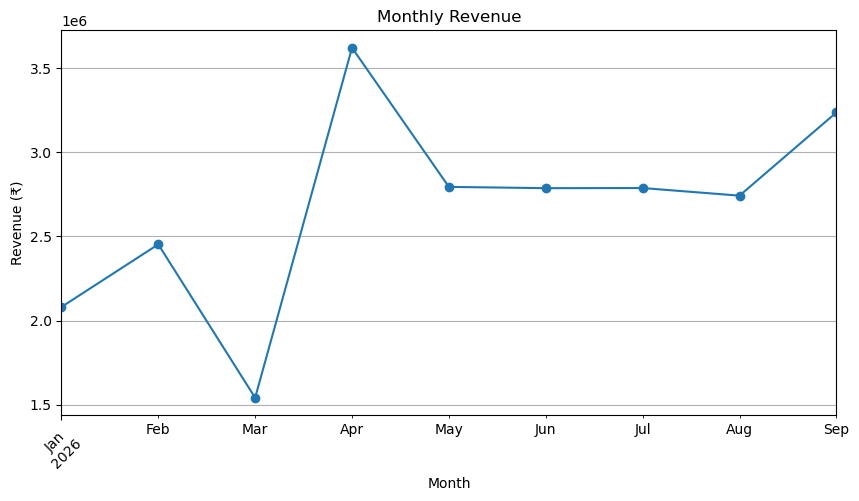

In [25]:
plt.figure(figsize=(10, 5))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [26]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(category_revenue)

Category
Electronics    18378750.0
Furniture       2749950.0
Accessories     1234845.0
Clothing         875825.0
Footwear         802375.0
Name: Revenue, dtype: float64


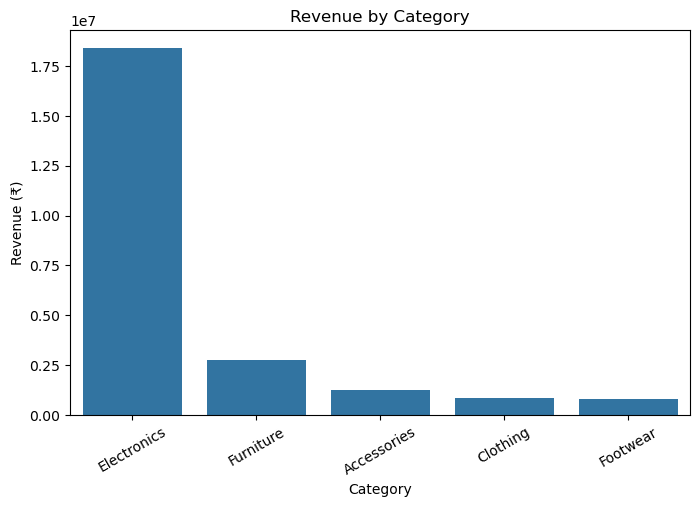

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

plt.show()

In [28]:
status_counts = df["OrderStatus"].value_counts()

print(status_counts)

OrderStatus
Delivered    880
Returned      74
Cancelled     46
Name: count, dtype: int64


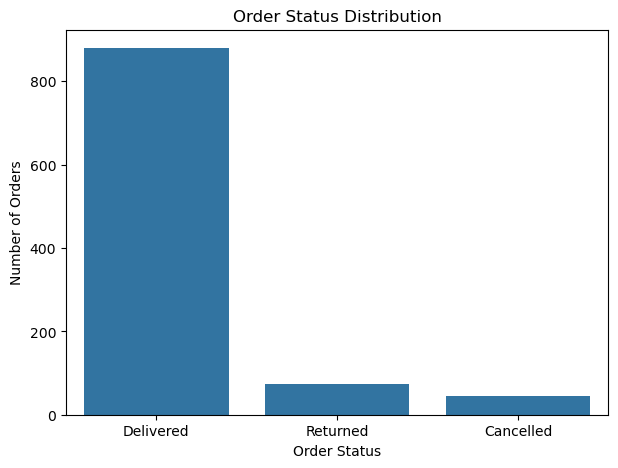

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()